# ZDT1 Results

In [6]:
from meamt_core import build_toolbox, gen_inicial_tables, run, generate_zdt1_front_true
from deap import benchmarks
import matplotlib.pyplot as plt
# 1. Parâmetros (Substituindo as antigas variáveis globais)
IND_SIZE = 30
NPOP = 100
NGEN = 200
NOBJ = 2
NUM_TABLES = int((1 << NOBJ))
MAX_TABLE_SIZE = int(NPOP / NUM_TABLES)
REF_POINT_HV = [1.1] * NOBJ

# 2. Configurando o Toolbox para o DTLZ3
def func_zdt1(ind):
    return benchmarks.zdt1(ind)

# 3. Inicialização e Execução
toolbox = build_toolbox(func_zdt1, IND_SIZE, NPOP, NOBJ)
pop_inicial = toolbox.population()
for ind in pop_inicial:
    ind.fitness.values = toolbox.evaluate(ind)

tabelas = gen_inicial_tables(pop_inicial, NUM_TABLES, MAX_TABLE_SIZE, NOBJ)

pareto_real = generate_zdt1_front_true(10000, IND_SIZE)

# 5. Rodando o MEAMT
logbook = run(tabelas, pareto_real, NUM_TABLES, MAX_TABLE_SIZE, NGEN, toolbox, 0.9, 1.0, REF_POINT_HV, NOBJ)

[[0.7918309077137087, 0.11015118828325188], [0.7505839202933543, 0.13363753526981892], [0.109394899735758, 0.669251001912692], [0.984692650328064, 0.007683190544439111], [0.37721433289282214, 0.38582223021927753], [0.9303254183410063, 0.035466217107453346], [0.21742201071113698, 0.5337146681364113], [0.9694936981218608, 0.015371289204981209], [0.8544343309452321, 0.0756438289570237], [0.35693950264536634, 0.40255585813787886], [0.059063506945332245, 0.7569701521513618], [0.04633058654565769, 0.7847545899544948], [0.43742146272647464, 0.3386215434968609], [0.4747515033073967, 0.31097786442858266], [0.14383549601649637, 0.6207434957492537], [0.2501217600370629, 0.4998782547848345], [0.0677896668121446, 0.7396355116146893], [0.7061746499747654, 0.15965801605848262], [0.8966045255659981, 0.05310796520089045], [0.585167033406654, 0.23503788760053357], [0.9963134523583899, 0.0018449757886354057], [0.02522023109734428, 0.8411912121532807], [0.9457244038923962, 0.027516373457940335], [0.681590

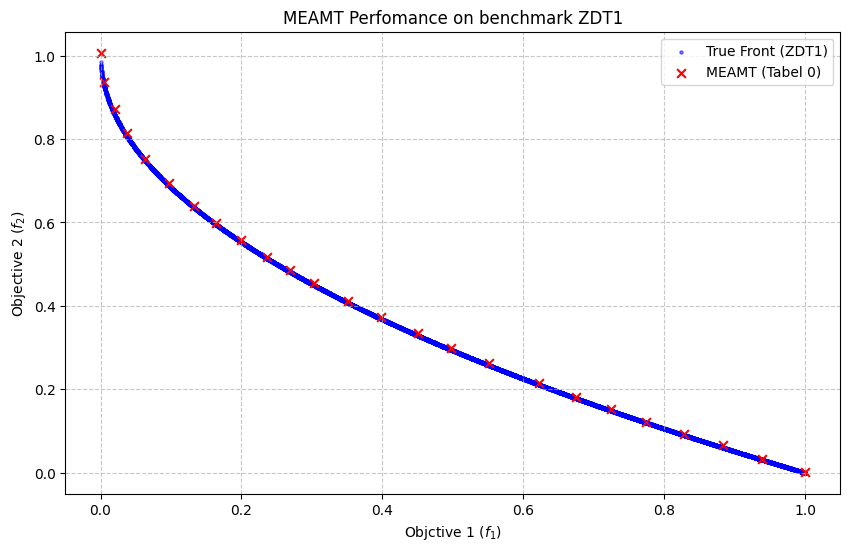

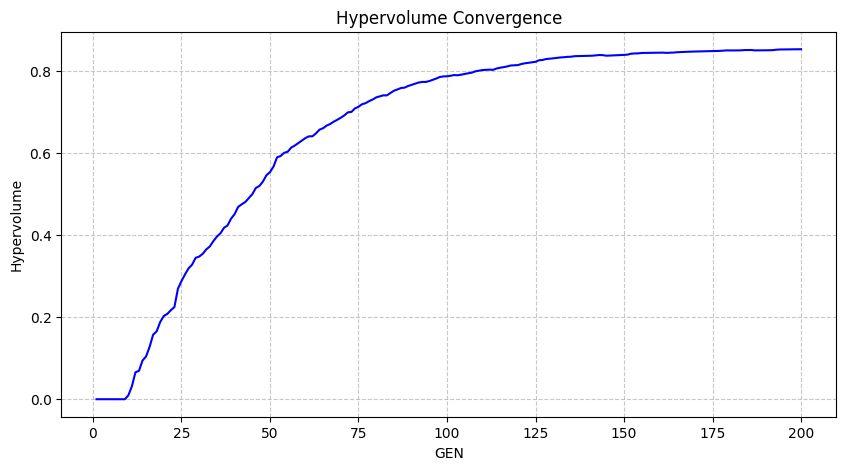

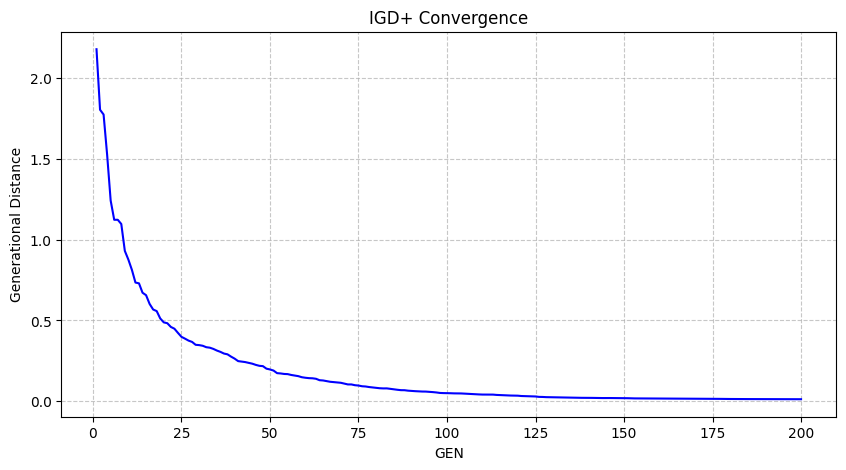

In [7]:
print(pareto_real)
f1_approx = [ind.fitness.values[0] for ind in tabelas[0]]
f2_approx = [ind.fitness.values[1] for ind in tabelas[0]]

f1_true = [linha[0] for linha in pareto_real]
f2_true = [linha[1] for linha in pareto_real]


plt.figure(figsize=(10, 6))


plt.scatter(f1_true, f2_true, color='blue', s=5, alpha=0.5, label='True Front (ZDT1)')


plt.scatter(f1_approx, f2_approx, color='red', marker='x', s=40, label='MEAMT (Tabel 0)')

plt.title("MEAMT Perfomance on benchmark ZDT1")
plt.xlabel("Objctive 1 ($f_1$)")
plt.ylabel("Objective 2 ($f_2$)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Exibe o gráfico
plt.show()

# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()